In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/cleaned_data.csv")
df.columns

Index(['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent',
       'previous_scores', 'exam_score'],
      dtype='object')

In [2]:
# Drop non-feature column before splitting
X = df.drop(columns=["exam_score", "student_id"], errors="ignore")
y = df["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67
)

# Verify the sizes
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 160
Testing set size: 40


# Evaluation

In [3]:
import sys
from pathlib import Path

# Adds the project root (one level up from /notebooks) to the search path
sys.path.append(str(Path.cwd().parent))

# Now your imports will work perfectly
from src.statsmodel_model import StatsModelsLinearRegression
from src.equation_model import EquationLinearRegression
from src.gd_model import GradientDescentLinearRegression
from src.scikit_model import SklearnLinearRegression
from src.lin_reg_strategy import LinearRegressionStrategy

models: list[LinearRegressionStrategy] = []

stats_model = StatsModelsLinearRegression()
models.append(stats_model)
equation_model = EquationLinearRegression()
models.append(equation_model)
gd_model = GradientDescentLinearRegression()
models.append(gd_model)
sklearn_model = SklearnLinearRegression()
models.append(sklearn_model)

## Fit & Collect Metrics

In [4]:
import importlib
import src.statsmodel_model
importlib.reload(src.statsmodel_model)
from src.statsmodel_model import StatsModelsLinearRegression


X_train_arr = X_train.to_numpy()
X_test_arr  = X_test.to_numpy()
y_train_arr = y_train.to_numpy()
y_test_arr  = y_test.to_numpy()

results: list[dict] = []

for model in models:
    model.fit(X_train_arr, y_train_arr)

    train_pred = model.predict(X_train_arr)
    test_pred  = model.predict(X_test_arr)

    train_mse = model.mse(y_train_arr, train_pred)
    test_mse  = model.mse(y_test_arr,  test_pred)
    train_r2  = model.r_squared(y_train_arr, train_pred)
    test_r2   = model.r_squared(y_test_arr,  test_pred)

    results.append({
        "model":      model.name(),
        "train_mse":  train_mse,
        "test_mse":   test_mse,
        "train_rmse": np.sqrt(train_mse),
        "test_rmse":  np.sqrt(test_mse),
        "train_r2":   train_r2,
        "test_r2":    test_r2,
        "test_pred":  test_pred,
    })

metrics_df = pd.DataFrame(results).drop(columns=["test_pred"])
metrics_df = metrics_df.set_index("model").round(4)
metrics_df

,train_mse,test_mse,train_rmse,test_rmse,train_r2,test_r2
model,,,,,,
Stats model,28.864,29.921,5.3725,5.47,0.8496,0.7923
Equation Model,28.864,29.921,5.3725,5.47,0.8496,0.7923
Gradient Decent model,28.864,29.921,5.3725,5.47,0.8496,0.7923
SKLearn model,28.864,29.921,5.3725,5.47,0.8496,0.7923


## Comparison Plots

FileNotFoundError: [Errno 2] No such file or directory: '../reports/metrics_comparison.png'

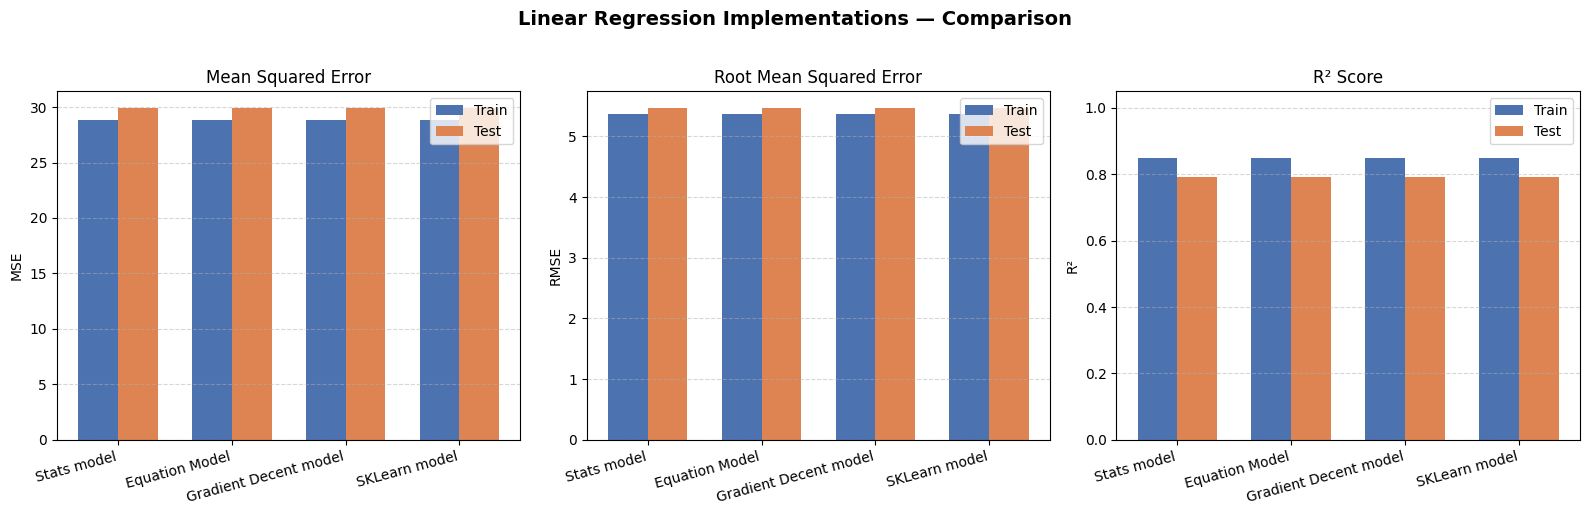

In [5]:
model_names = [r["model"] for r in results]
x_pos       = np.arange(len(model_names))
bar_width   = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Linear Regression Implementations — Comparison", fontsize=14, fontweight="bold", y=1.02)

palette_train = "#4C72B0"
palette_test  = "#DD8452"

# --- MSE ---
ax = axes[0]
ax.bar(x_pos - bar_width/2, [r["train_mse"] for r in results], bar_width, label="Train", color=palette_train)
ax.bar(x_pos + bar_width/2, [r["test_mse"]  for r in results], bar_width, label="Test",  color=palette_test)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_title("Mean Squared Error")
ax.set_ylabel("MSE")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

# --- RMSE ---
ax = axes[1]
ax.bar(x_pos - bar_width/2, [r["train_rmse"] for r in results], bar_width, label="Train", color=palette_train)
ax.bar(x_pos + bar_width/2, [r["test_rmse"]  for r in results], bar_width, label="Test",  color=palette_test)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_title("Root Mean Squared Error")
ax.set_ylabel("RMSE")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

# --- R² ---
ax = axes[2]
ax.bar(x_pos - bar_width/2, [r["train_r2"] for r in results], bar_width, label="Train", color=palette_train)
ax.bar(x_pos + bar_width/2, [r["test_r2"]  for r in results], bar_width, label="Test",  color=palette_test)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_title("R² Score")
ax.set_ylabel("R²")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../reports/metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../reports/predicted_vs_actual.png'

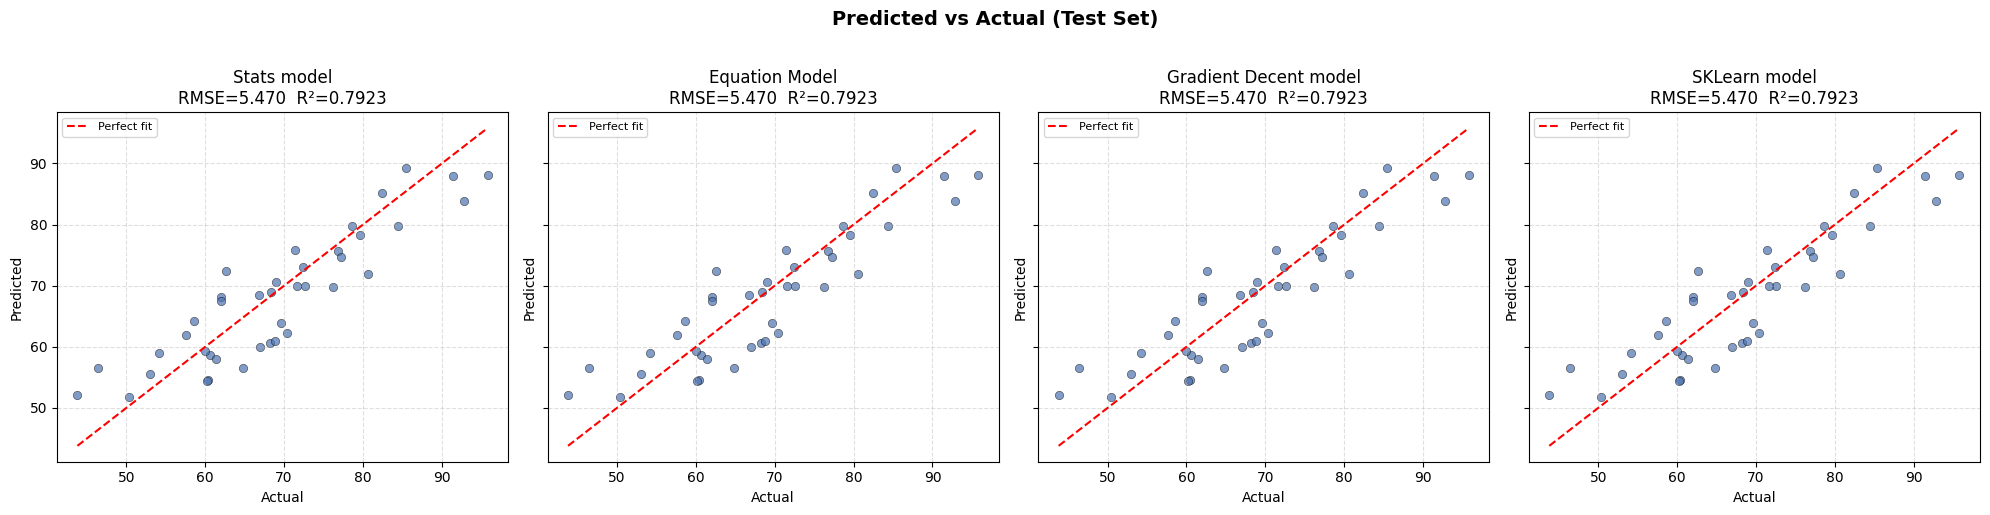

In [6]:
# Predicted vs Actual — one scatter per model
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True)
fig.suptitle("Predicted vs Actual (Test Set)", fontsize=14, fontweight="bold", y=1.02)

y_min = y_test_arr.min()
y_max = y_test_arr.max()

for ax, r in zip(axes, results):
    ax.scatter(y_test_arr, r["test_pred"], alpha=0.7, edgecolors="k", linewidths=0.4, color="#4C72B0")
    ax.plot([y_min, y_max], [y_min, y_max], "r--", linewidth=1.5, label="Perfect fit")
    ax.set_title(f"{r['model']}\nRMSE={r['test_rmse']:.3f}  R²={r['test_r2']:.4f}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend(fontsize=8)
    ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../reports/predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

## Residual Analysis

FileNotFoundError: [Errno 2] No such file or directory: '../reports/residuals.png'

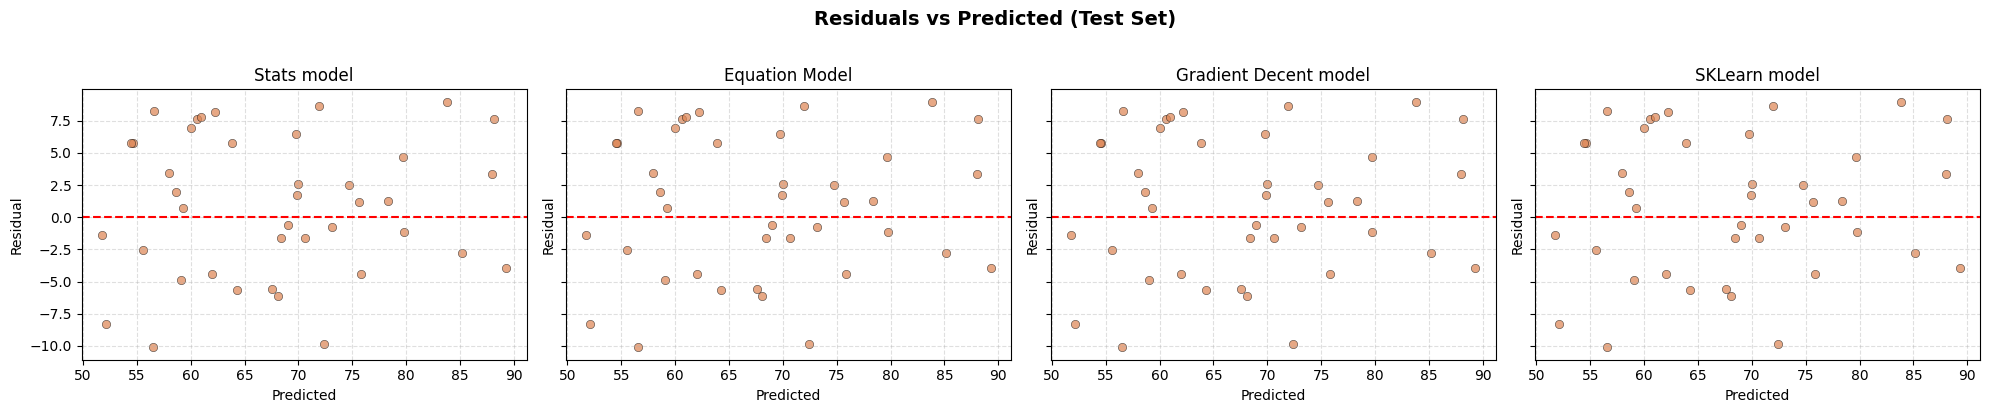

In [7]:
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), sharey=True)
fig.suptitle("Residuals vs Predicted (Test Set)", fontsize=14, fontweight="bold", y=1.02)

for ax, r in zip(axes, results):
    residuals = y_test_arr - r["test_pred"]
    ax.scatter(r["test_pred"], residuals, alpha=0.7, edgecolors="k", linewidths=0.4, color="#DD8452")
    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(r["model"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")
    ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../reports/residuals.png", dpi=150, bbox_inches="tight")
plt.show()